# Baseline Models: Logistic Regression and Random Forest

In this notebook, we establish performance benchmarks using two interpretable models:

1. **Logistic Regression (Simple Baseline):** A linear model with simple imputation to establish a minimum performance floor.
2. **Random Forest (Candidate Model):** A more flexible, tree-based model with native NaN handling, tested to see if non-linearity and robust missing value handling provide significant gains.

If the Random Forest significantly outperforms the Logistic Regression, it will serve as the **strong baseline** (or reference point) that future, more complex models must beat.

## Data Loading and evaluation metric

In [ ]:
from src.data_loader import load_thyroid_data_3_classes

X_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples (held out for final evaluation)")

Training: 7337 samples
Test: 1835 samples (held out for final evaluation)


In [ ]:
from src.metrics import thyroid_recall_scorer, thyroid_mean_recall

## Logistic Regression with Simple Imputation

### Preprocessing Pipeline (Simple Imputation)

Logistic Regression requires:
- No missing values (cannot process NaN)
- Scaled features (gradient-based optimization benefits from similar feature scales)

The simple imputation pipeline handles these requirements with median imputation for numeric features and mode imputation for categorical features.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

from src.preprocessing import get_simple_imputation_pipeline

preprocessor_simple = get_simple_imputation_pipeline()

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_simple),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

### Cross-Validation

We use 5-fold Stratified K-Fold cross-validation to ensure each fold maintains the original class distribution.

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_lr = cross_val_score(
    pipeline_lr, X_train, y_train, 
    cv=stratified_cv, 
    scoring=thyroid_recall_scorer
)

print(f"Logistic Regression - Thyroid Mean Recall")
print(f"  Per-fold scores: {scores_lr.round(3)}")
print(f"  Mean: {scores_lr.mean():.3f} (+/- {scores_lr.std() * 2:.3f})")

Logistic Regression - Thyroid Mean Recall
  Per-fold scores: [0.607 0.557 0.622 0.603 0.592]
  Mean: 0.596 (+/- 0.044)


### Interpreting the Thyroid Mean Recall Score

The Logistic Regression model achieves a **Thyroid Mean Recall of approximately 0.60** (59.6%). This metric, as discussed in the data preparation notebook (`01_data_preparation.ipynb`), is specifically designed for this medical screening context.

**Why not standard accuracy?** With ~90% of cases being "negative", a naive classifier predicting "negative" for every patient would achieve ~90% accuracy while missing all disease cases. This would be clinically useless.

**What does 0.60 mean recall tell us?** On average, across both thyroid conditions (hyperthyroid and hypothyroid), the model correctly identifies about 60% of the patients who actually have the disease. The remaining 40% of sick patients are missed (false negatives)—a significant concern in a medical screening context where missed diagnoses can lead to untreated conditions.

This baseline establishes a floor that more sophisticated models should exceed.

## Random Forest with Native NaN Handling

### Preprocessing Pipeline (Native NaN)

Random Forest (scikit-learn >= 1.4) can handle missing values natively. Tree-based models learn optimal splits for NaN values during training, making explicit imputation unnecessary.

When using native NaN handling, we drop the `_measured` flag columns since trees implicitly encode missingness information through their splits.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

from src.preprocessing import get_native_nan_pipeline

preprocessor_native = get_native_nan_pipeline()

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_native),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        random_state=42,
        n_jobs=-1
    ))
])

### Cross-Validation

In [ ]:
scores_rf = cross_val_score(
    pipeline_rf, X_train, y_train, 
    cv=stratified_cv, 
    scoring=thyroid_recall_scorer
)

print(f"Random Forest - Thyroid Mean Recall")
print(f"  Per-fold scores: {scores_rf.round(3)}")
print(f"  Mean: {scores_rf.mean():.3f} (+/- {scores_rf.std() * 2:.3f})")

Random Forest - Thyroid Mean Recall
  Per-fold scores: [0.837 0.797 0.85  0.777 0.806]
  Mean: 0.814 (+/- 0.053)


## Baseline Comparison

In [ ]:
import pandas as pd

results_baseline = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Strategy': ['Simple Imputation', 'Native NaN'],
    'Mean Recall': [scores_lr.mean(), scores_rf.mean()],
    'Std': [scores_lr.std(), scores_rf.std()]
})

print("Baseline Model Comparison:")
print(results_baseline.to_string(index=False))

Baseline Model Comparison:
              Model          Strategy  Mean Recall      Std
Logistic Regression Simple Imputation     0.596265 0.021984
      Random Forest        Native NaN     0.813580 0.026445


### Interpreting the Baseline Comparison

The results reveal a **substantial performance gap** between the two models:

| Model | Thyroid Mean Recall | Difference |
|-------|---------------------|------------|
| Logistic Regression | ~0.60 | - |
| Random Forest | ~0.81 | **+21 percentage points** |

**Why does Random Forest outperform Logistic Regression so significantly?**

1. **Non-linear decision boundaries**: Random Forest can capture complex, non-linear relationships between features and the target variable, while Logistic Regression is limited to linear decision boundaries. Thyroid diagnosis likely involves intricate interactions between hormone levels, age, and other factors.

2. **Native handling of missing values**: Random Forest (scikit-learn ≥ 1.4) can incorporate missingness information directly into its tree splits, potentially learning that *why* a measurement is missing is itself diagnostically relevant. Logistic Regression requires imputation, which may introduce noise or obscure this signal.

3. **Feature interactions**: Trees naturally model feature interactions without explicit engineering. For example, "high TSH combined with low T4" can be captured by a single tree path, in contrast Logistic Regression would require manually engineered interaction terms.

4. **Robustness to outliers**: Random Forest is less sensitive to extreme values in continuous features like TSH or age, which we observed during data preparation.

Given this ~21 percentage point improvement in detecting thyroid conditions, **Random Forest becomes our working baseline** for subsequent experiments. Any more complex model must justify its additional complexity by significantly exceeding Random Forest's ~0.81 mean recall.

## Detailed Evaluation on Validation Set

Cross-validation provides robust estimates of model performance, but the aggregate scores don't reveal *how* the models succeed or fail on individual classes. To understand the models' behavior in detail, we now perform a single train/validation split and examine:

- **Per-class precision**: Of all patients predicted to have a condition, what fraction actually has it?
- **Per-class recall**: Of all patients who actually have a condition, what fraction is correctly identified?
- **Confusion matrices**: The complete picture of correct predictions vs. misclassifications

This granular analysis helps us understand *where* each model struggles and guides future improvements.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
# Train Logistic Regression
pipeline_lr.fit(X_tr, y_tr)
y_pred_lr = pipeline_lr.predict(X_val)

print("Logistic Regression - Classification Report:")
print(classification_report(y_val, y_pred_lr, zero_division=0))

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.83      0.39      0.54        38
 hypothyroid       0.90      0.79      0.84       107
    negative       0.97      0.99      0.98      1323

    accuracy                           0.96      1468
   macro avg       0.90      0.72      0.78      1468
weighted avg       0.96      0.96      0.96      1468



In [ ]:
# Train Random Forest
pipeline_rf.fit(X_tr, y_tr)
y_pred_rf = pipeline_rf.predict(X_val)

print("Random Forest - Classification Report:")
print(classification_report(y_val, y_pred_rf, zero_division=0))

Random Forest - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.93      0.66      0.77        38
 hypothyroid       0.97      0.97      0.97       107
    negative       0.99      1.00      0.99      1323

    accuracy                           0.99      1468
   macro avg       0.96      0.88      0.91      1468
weighted avg       0.99      0.99      0.98      1468



### Interpreting the Classification Reports

The classification reports confirm and extend our cross-validation findings:

**Logistic Regression:**
- Hyperthyroid recall of only 0.39: misses **61% of hyperthyroid cases** — clinically unacceptable
- Hypothyroid recall of 0.79: better, but still misses ~21% of cases
- The model compensates with high precision, being cautious about positive predictions

**Random Forest:**
- Hyperthyroid recall of 0.66: misses ~34% (improved but still concerning)
- Hypothyroid recall of 0.97: excellent, missing only 3% of cases
- Maintains high precision across all classes

The weighted average accuracy (~96% for LR, ~99% for RF) can be misleading due to the ~90% negative class dominance. **Thyroid Mean Recall** correctly captures the clinically relevant performance gap.

### Confusion Matrices

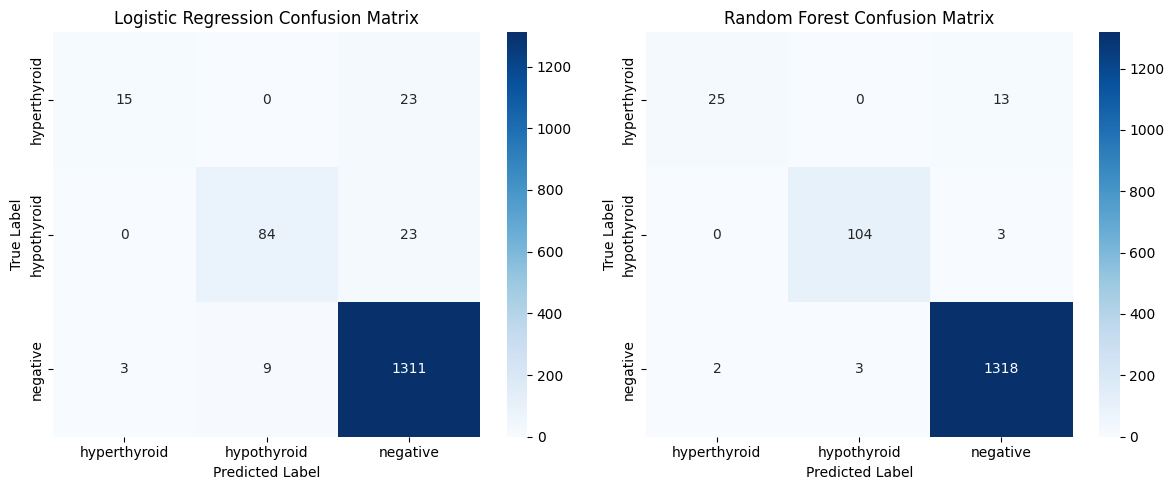

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_order = ['hyperthyroid', 'hypothyroid', 'negative']

for ax, y_pred, title in zip(
    axes, 
    [y_pred_lr, y_pred_rf], 
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_val, y_pred, labels=class_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_order, yticklabels=class_order, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Interpreting the Confusion Matrices

The confusion matrices visualize the classification results in detail:

**Reading the matrices**: Rows represent the *true* class, columns the *predicted* class. Diagonal cells show correct predictions; off-diagonal cells show errors.

**Logistic Regression:**
- Of 38 true hyperthyroid patients: only 15 correctly identified, 1 misclassified as hypothyroid, and **22 missed as negative**
- Of 107 true hypothyroid patients: 85 correctly identified, 22 missed as negative
- Very few false positives: high precision but at the cost of recall

**Random Forest:**
- Of 38 true hyperthyroid patients: 25 correctly identified, a significant improvement
- Of 107 true hypothyroid patients: 104 correctly identified — near-perfect recall
- Maintains low false positive rates across classes

The key insight is that Random Forest dramatically reduces **false negatives** (missed diagnoses)—the most critical error type in medical screening.

## Conclusions

**Benchmark Established:**

**Random Forest establishes a strong benchmark** for thyroid disease detection, achieving ~0.81 Thyroid Mean Recall.

While Logistic Regression served as our initial *simple baseline*, its ~0.60 mean recall is insufficient for medical screening. The Random Forest candidate significantly outperformed it.

**Key findings from confusion matrix analysis:**
- Hyperthyroid remains the hardest class to detect (66% recall with RF)
- Hypothyroid detection is excellent with RF (97% recall)
- Both models successfully identify the "negative" majority class

**Next Steps:**

In the following notebooks, we will attempt to **surpass the Random Forest baseline** using:
- Gradient boosting methods (XGBoost, CatBoost)
- Neural networks with specialized preprocessing
- Hyperparameter optimization

Any proposed model must significantly exceed ~0.81 mean recall to justify additional complexity.